# Sokoban Gymnasium Tutorial

This notebook demonstrates how to use the gym_sokoban environment with Gymnasium 1.0.0.

## What is Sokoban?

Sokoban is a classic puzzle game where the player must push boxes onto target locations. The environment provides:
- **9 discrete actions**: Move up, down, left, right, push box in any direction, or no-op
- **RGB observations**: Visual representation of the game state
- **Reward shaping**: Penalties for steps and rewards for placing boxes on targets
- **Episode termination**: When all boxes are on targets (terminated) or max steps reached (truncated)

## Setup and Installation

Make sure you have gymnasium installed:
```bash
pip install gymnasium numpy matplotlib
```

In [13]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from gym_sokoban.envs import SokobanEnv

# Set up matplotlib for displaying images
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 8)

## 1. Creating an Environment

There are two ways to create a Sokoban environment:

### Method 1: Direct Creation

In [14]:
# Create environment with custom parameters
env = SokobanEnv(
    dim_room=(7, 7),        # Room dimensions (height, width)
    max_steps=120,          # Maximum steps before truncation
    num_boxes=2,            # Number of boxes to push
    render_mode='rgb_array' # Render mode: 'rgb_array', 'human', 'tiny_rgb_array', 'raw'
)

print(f"Action space: {env.action_space}")
print(f"Observation space: {env.observation_space}")

Action space: Discrete(9)
Observation space: Box(0, 255, (112, 112, 3), uint8)


### Method 2: Using gym.make()

You can also use the standard gymnasium registration system:

In [15]:
# Create environment using gym.make
env_registered = gym.make('Sokoban-v0', render_mode='rgb_array')
print(f"Registered environment: {env_registered}")

Registered environment: <OrderEnforcing<PassiveEnvChecker<SokobanEnv1<Sokoban-v0>>>>


## 2. Understanding Actions

The environment has 9 discrete actions:

In [16]:
# Action mapping
ACTION_NAMES = [
    "No-Op",           # 0
    "Push Up",         # 1
    "Push Down",       # 2
    "Push Left",       # 3
    "Push Right",      # 4
    "Move Up",         # 5
    "Move Down",       # 6
    "Move Left",       # 7
    "Move Right"       # 8
]

for i, name in enumerate(ACTION_NAMES):
    print(f"Action {i}: {name}")

Action 0: No-Op
Action 1: Push Up
Action 2: Push Down
Action 3: Push Left
Action 4: Push Right
Action 5: Move Up
Action 6: Move Down
Action 7: Move Left
Action 8: Move Right


## 3. Basic Environment Interaction

Let's see how to interact with the environment using the gymnasium API.

### Reset the Environment

Observation shape: (112, 112, 3)
Observation dtype: uint8
Info: {}


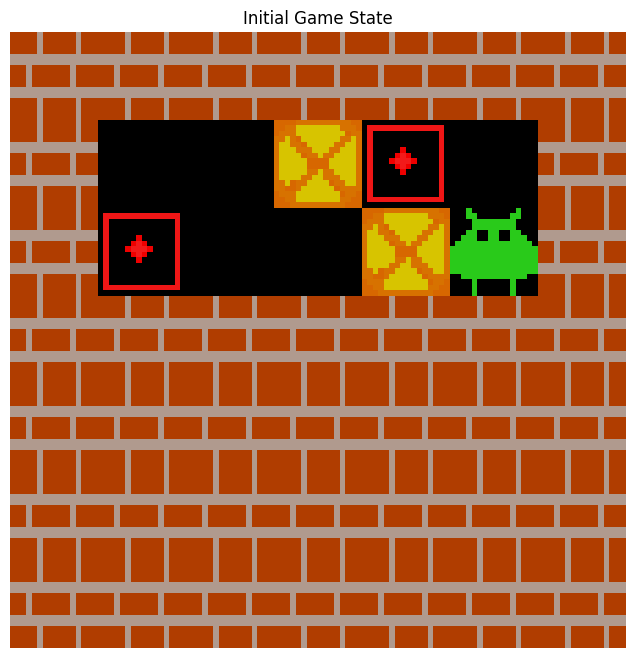

In [17]:
# Reset environment with a seed for reproducibility
observation, info = env.reset(seed=42)

print(f"Observation shape: {observation.shape}")
print(f"Observation dtype: {observation.dtype}")
print(f"Info: {info}")

# Display the initial state
plt.imshow(observation)
plt.title("Initial Game State")
plt.axis('off')
plt.show()

### Take a Step

Action taken: Push Right
Reward: 10.9
Terminated (goal reached): True
Truncated (max steps): False
Info: {'action.name': 'push right', 'action.moved_player': True, 'action.moved_box': True, 'maxsteps_used': False, 'all_boxes_on_target': True}


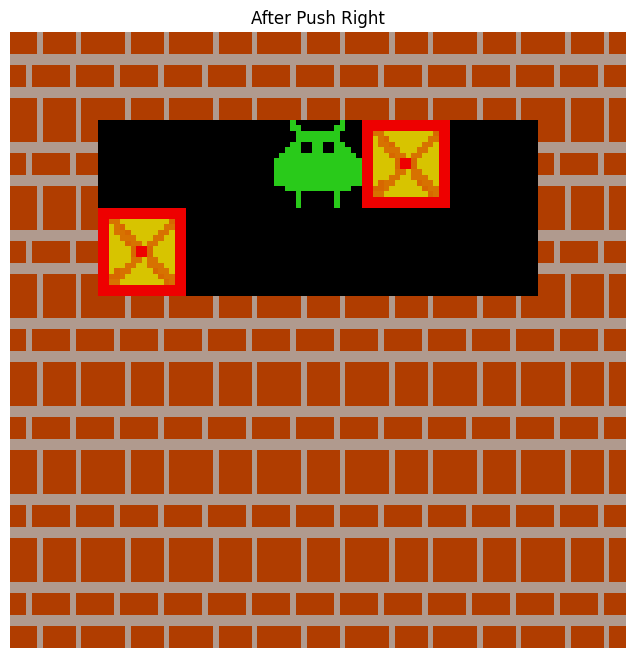

In [23]:
# Take an action (move right)
action = 4  # Move Right
observation, reward, terminated, truncated, info = env.step(action)

print(f"Action taken: {ACTION_NAMES[action]}")
print(f"Reward: {reward}")
print(f"Terminated (goal reached): {terminated}")
print(f"Truncated (max steps): {truncated}")
print(f"Info: {info}")

# Display the new state
plt.imshow(observation)
plt.title(f"After {ACTION_NAMES[action]}")
plt.axis('off')
plt.show()

## 4. Running a Full Episode

Let's run a full episode with random actions and visualize key moments.

In [24]:
# Reset environment
observation, info = env.reset(seed=123)

# Store data for analysis
total_reward = 0
step_count = 0
observations = [observation]
rewards = []

# Run episode
while True:
    action = env.action_space.sample()  # Random action
    observation, reward, terminated, truncated, info = env.step(action)
    
    total_reward += reward
    step_count += 1
    
    observations.append(observation)
    rewards.append(reward)
    
    # Save observations at key moments (every 20 steps)
    if step_count % 20 == 0:
        print(f"Step {step_count}: Reward = {reward:.2f}, Total = {total_reward:.2f}")
    
    if terminated or truncated:
        break

print(f"\n=== Episode Finished ===")
print(f"Total steps: {step_count}")
print(f"Total reward: {total_reward:.2f}")
print(f"Goal reached: {info.get('all_boxes_on_target', False)}")
print(f"Max steps reached: {info.get('maxsteps_used', False)}")

Step 20: Reward = -0.10, Total = -2.00
Step 40: Reward = -0.10, Total = -4.00
Step 60: Reward = -0.10, Total = -6.00
Step 80: Reward = -0.10, Total = -8.00
Step 100: Reward = -0.10, Total = -10.00
Step 120: Reward = -0.10, Total = -12.00

=== Episode Finished ===
Total steps: 120
Total reward: -12.00
Goal reached: False
Max steps reached: True


### Visualize Episode Progress

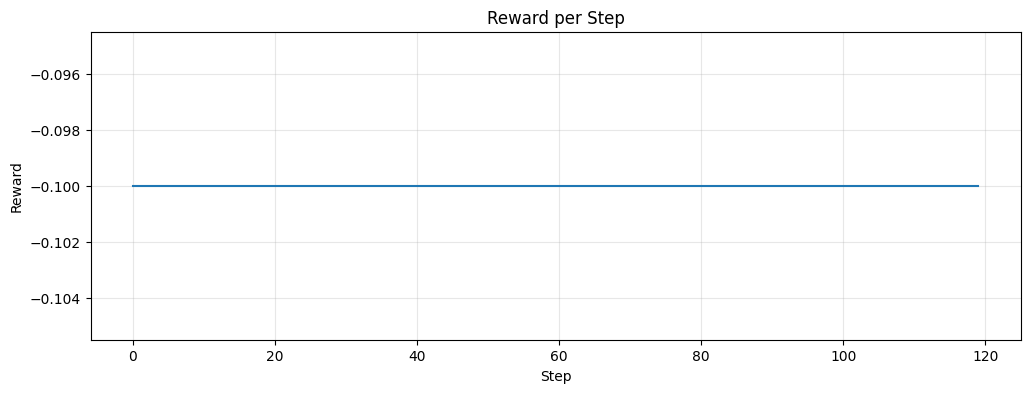

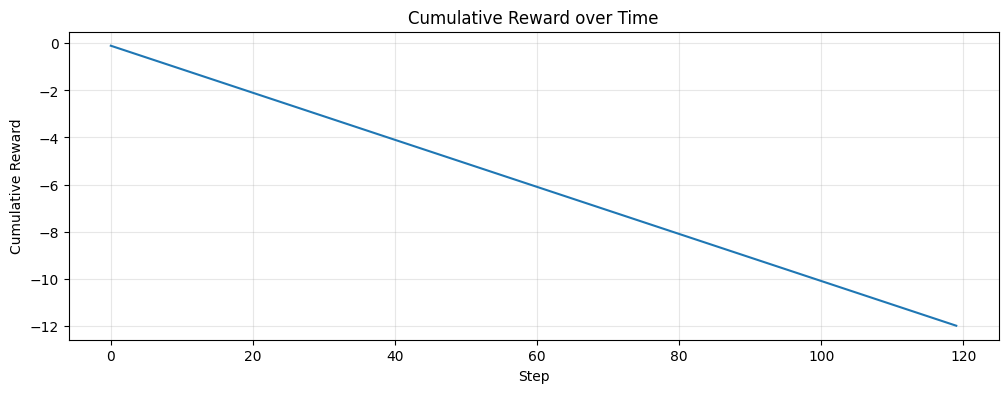

In [25]:
# Plot rewards over time
plt.figure(figsize=(12, 4))
plt.plot(rewards)
plt.xlabel('Step')
plt.ylabel('Reward')
plt.title('Reward per Step')
plt.grid(True, alpha=0.3)
plt.show()

# Plot cumulative reward
plt.figure(figsize=(12, 4))
plt.plot(np.cumsum(rewards))
plt.xlabel('Step')
plt.ylabel('Cumulative Reward')
plt.title('Cumulative Reward over Time')
plt.grid(True, alpha=0.3)
plt.show()

### Visualize Key Moments in the Episode

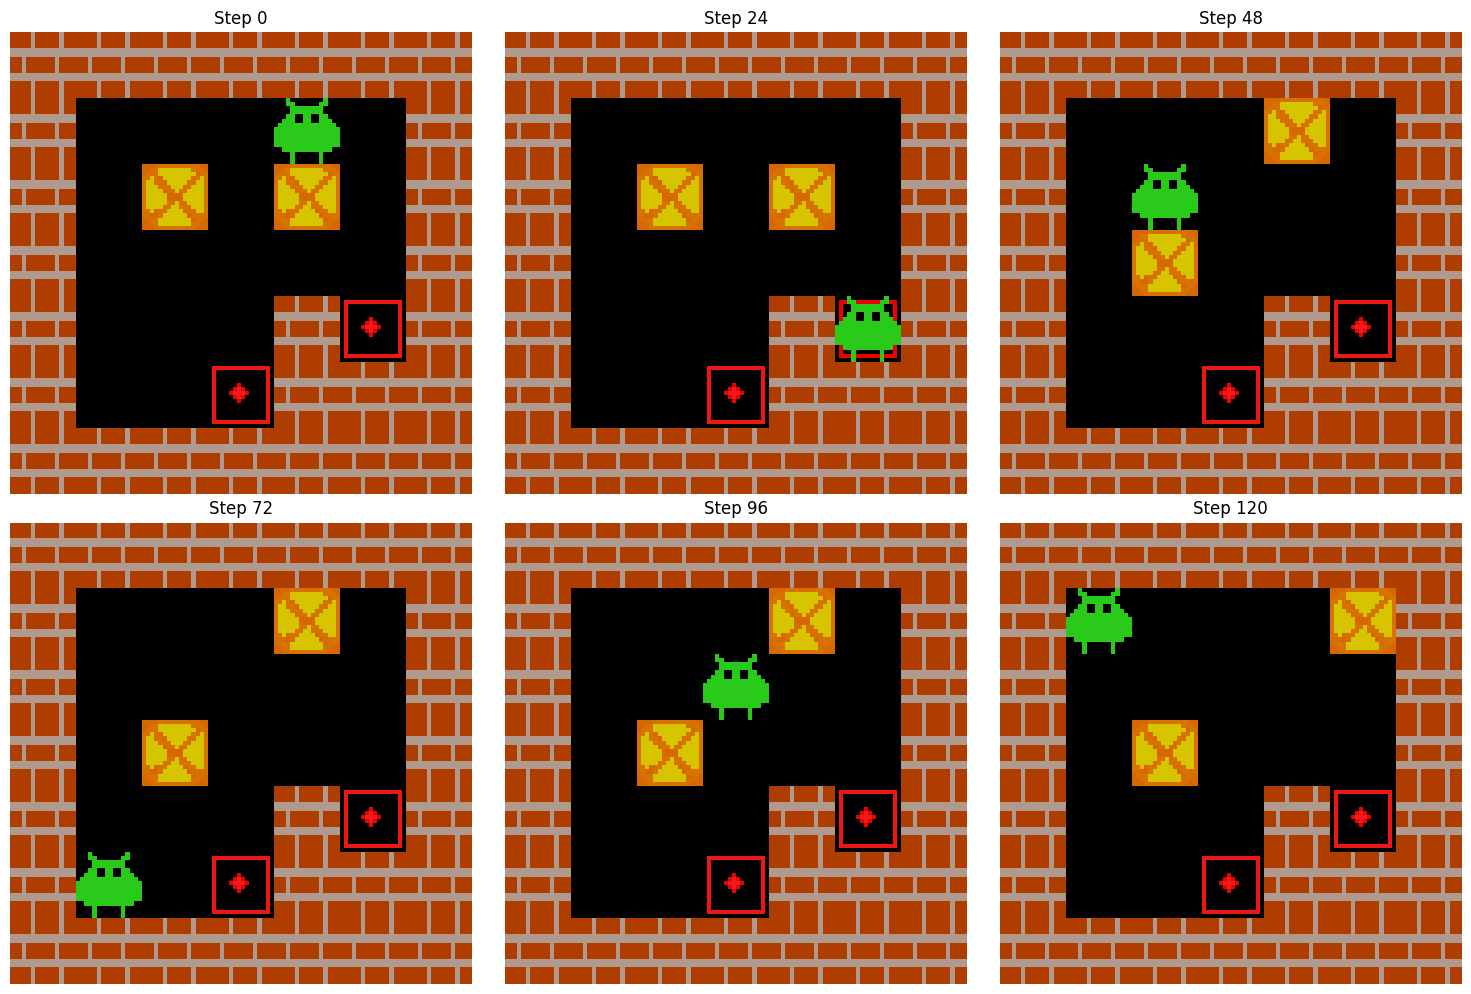

In [26]:
# Show snapshots at different points
num_snapshots = 6
snapshot_indices = np.linspace(0, len(observations)-1, num_snapshots, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(snapshot_indices):
    axes[i].imshow(observations[idx])
    axes[i].set_title(f'Step {idx}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 5. Understanding Rewards

The reward structure is:
- **-0.1**: Penalty per step (encourages efficiency)
- **+1.0**: Reward for placing a box on a target
- **-1.0**: Penalty for moving a box off a target
- **+10.0**: Bonus reward for completing the puzzle

In [27]:
# Let's examine the reward structure
env_test = SokobanEnv(dim_room=(7, 7), max_steps=50, num_boxes=2, render_mode='rgb_array')
observation, info = env_test.reset(seed=999)

print("Testing different actions and their rewards:\n")

for i in range(5):
    action = env_test.action_space.sample()
    observation, reward, terminated, truncated, info = env_test.step(action)
    
    print(f"Step {i+1}:")
    print(f"  Action: {info['action.name']}")
    print(f"  Reward: {reward:.2f}")
    print(f"  Player moved: {info.get('action.moved_player', False)}")
    print(f"  Box moved: {info.get('action.moved_box', False)}")
    print()

env_test.close()

Testing different actions and their rewards:

Step 1:
  Action: push left
  Reward: -0.10
  Player moved: True
  Box moved: False

Step 2:
  Action: push down
  Reward: 0.90
  Player moved: True
  Box moved: True

Step 3:
  Action: move down
  Reward: -0.10
  Player moved: False
  Box moved: False

Step 4:
  Action: push down
  Reward: -1.10
  Player moved: True
  Box moved: True

Step 5:
  Action: push down
  Reward: -0.10
  Player moved: True
  Box moved: True



## 6. Working with Different Room Sizes

You can create environments with different configurations:

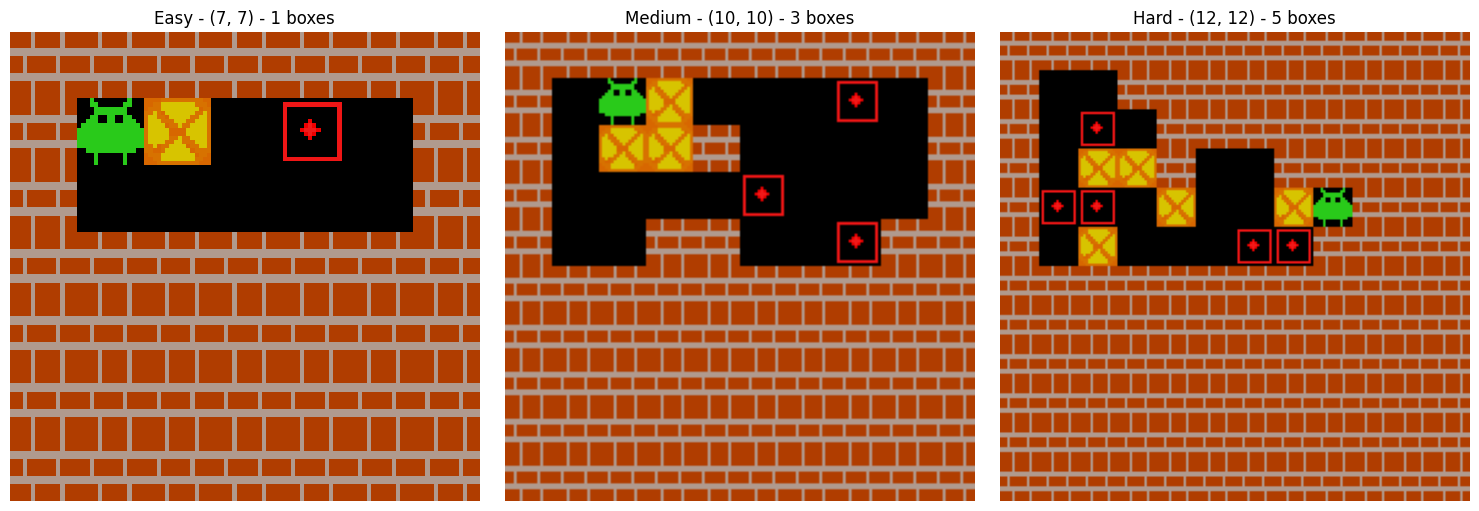

In [28]:
# Create environments with different difficulties
configs = [
    {"name": "Easy", "dim_room": (7, 7), "num_boxes": 1, "max_steps": 80},
    {"name": "Medium", "dim_room": (10, 10), "num_boxes": 3, "max_steps": 120},
    {"name": "Hard", "dim_room": (12, 12), "num_boxes": 5, "max_steps": 200},
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, config in enumerate(configs):
    env_temp = SokobanEnv(
        dim_room=config["dim_room"],
        num_boxes=config["num_boxes"],
        max_steps=config["max_steps"],
        render_mode='rgb_array'
    )
    observation, info = env_temp.reset(seed=42)
    
    axes[i].imshow(observation)
    axes[i].set_title(f"{config['name']} - {config['dim_room']} - {config['num_boxes']} boxes")
    axes[i].axis('off')
    
    env_temp.close()

plt.tight_layout()
plt.show()

## 7. Seeding for Reproducibility

The environment supports seeding for reproducible experiments:

Same seed produces identical environments: True
Different seed produces different environment: True


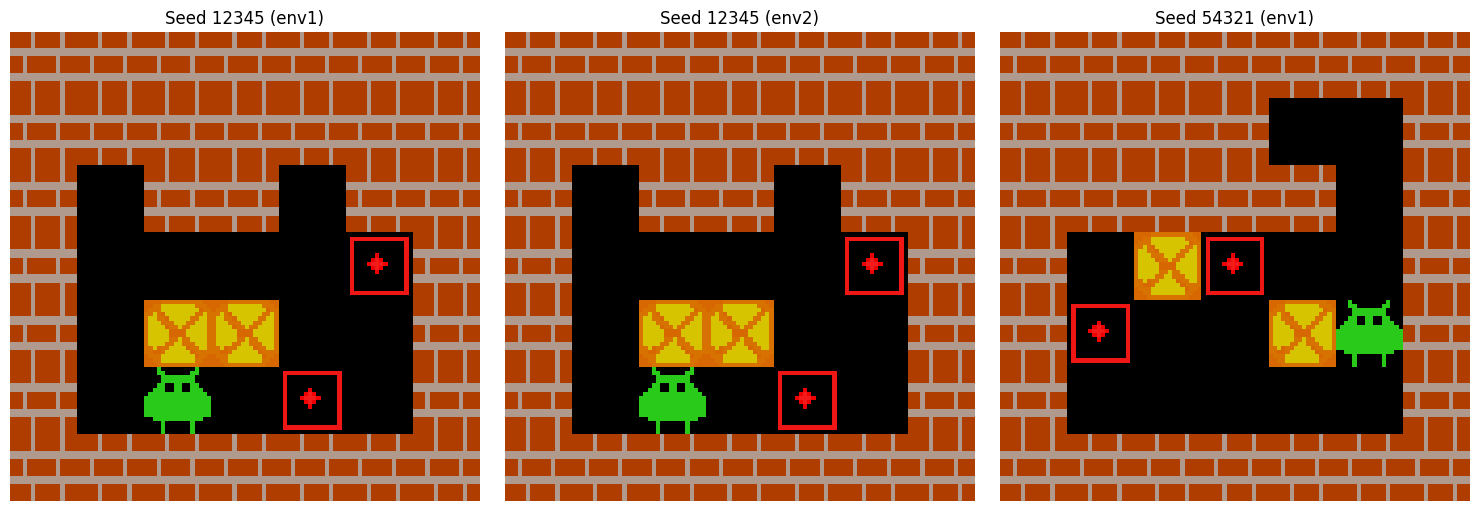

In [29]:
# Create two environments with the same seed
env1 = SokobanEnv(dim_room=(7, 7), num_boxes=2, render_mode='rgb_array')
env2 = SokobanEnv(dim_room=(7, 7), num_boxes=2, render_mode='rgb_array')

obs1, _ = env1.reset(seed=12345)
obs2, _ = env2.reset(seed=12345)

print(f"Same seed produces identical environments: {np.array_equal(obs1, obs2)}")

# Different seed produces different environment
obs3, _ = env1.reset(seed=54321)
print(f"Different seed produces different environment: {not np.array_equal(obs1, obs3)}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(obs1)
axes[0].set_title('Seed 12345 (env1)')
axes[0].axis('off')

axes[1].imshow(obs2)
axes[1].set_title('Seed 12345 (env2)')
axes[1].axis('off')

axes[2].imshow(obs3)
axes[2].set_title('Seed 54321 (env1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

env1.close()
env2.close()

## 8. Building a Simple Agent

Let's create a simple agent that tries to move towards boxes:

Agent completed episode in 100 steps
Total reward: -10.00
Goal reached: False


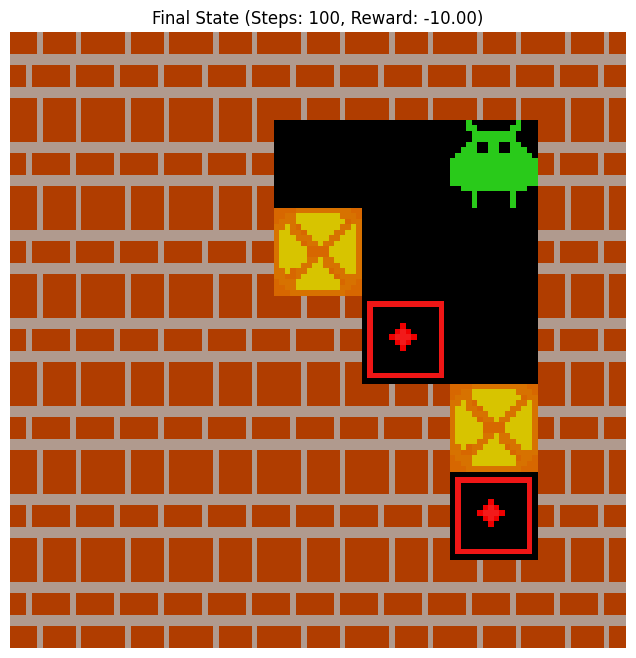

In [31]:
def simple_agent(observation, env):
    """
    A simple heuristic agent that takes random actions.
    In practice, you would use the observation to make intelligent decisions.
    """
    return env.action_space.sample()

# Test the agent
env_agent = SokobanEnv(dim_room=(7, 7), max_steps=100, num_boxes=2, render_mode='rgb_array')
observation, info = env_agent.reset(seed=777)

total_reward = 0
steps = 0

while True:
    action = simple_agent(observation, env_agent)
    observation, reward, terminated, truncated, info = env_agent.step(action)
    
    total_reward += reward
    steps += 1
    
    if terminated or truncated:
        break

print(f"Agent completed episode in {steps} steps")
print(f"Total reward: {total_reward:.2f}")
print(f"Goal reached: {info.get('all_boxes_on_target', False)}")

# Show final state
plt.imshow(observation)
plt.title(f"Final State (Steps: {steps}, Reward: {total_reward:.2f})")
plt.axis('off')
plt.show()

env_agent.close()

## 9. Batch Processing Multiple Episodes

Let's run multiple episodes and collect statistics:

In [32]:
def run_episode(env, seed=None, max_steps=None):
    """Run a single episode and return statistics."""
    observation, info = env.reset(seed=seed)
    total_reward = 0
    steps = 0
    
    while True:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)
        
        total_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
        
        if max_steps and steps >= max_steps:
            break
    
    return {
        'steps': steps,
        'total_reward': total_reward,
        'solved': info.get('all_boxes_on_target', False),
        'truncated': info.get('maxsteps_used', False)
    }

# Run multiple episodes
env_batch = SokobanEnv(dim_room=(7, 7), max_steps=100, num_boxes=2, render_mode='rgb_array')
num_episodes = 20

results = []
for i in range(num_episodes):
    result = run_episode(env_batch, seed=i)
    results.append(result)
    print(f"Episode {i+1}: Steps={result['steps']}, Reward={result['total_reward']:.2f}, Solved={result['solved']}")

env_batch.close()

# Calculate statistics
steps = [r['steps'] for r in results]
rewards = [r['total_reward'] for r in results]
solved = sum([r['solved'] for r in results])

print(f"\n=== Statistics over {num_episodes} episodes ===")
print(f"Average steps: {np.mean(steps):.2f} ± {np.std(steps):.2f}")
print(f"Average reward: {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
print(f"Success rate: {solved}/{num_episodes} ({100*solved/num_episodes:.1f}%)")

Episode 1: Steps=100, Reward=-10.00, Solved=False
Episode 2: Steps=100, Reward=-9.00, Solved=False
Episode 3: Steps=100, Reward=-10.00, Solved=False
Episode 4: Steps=100, Reward=-10.00, Solved=False
Episode 5: Steps=100, Reward=-9.00, Solved=False
Episode 6: Steps=100, Reward=-10.00, Solved=False
Episode 7: Steps=100, Reward=-9.00, Solved=False
Episode 8: Steps=100, Reward=-10.00, Solved=False
Episode 9: Steps=43, Reward=7.70, Solved=True
Episode 10: Steps=100, Reward=-9.00, Solved=False
Episode 11: Steps=100, Reward=-10.00, Solved=False
Episode 12: Steps=100, Reward=-10.00, Solved=False
Episode 13: Steps=100, Reward=-10.00, Solved=False
Episode 14: Steps=100, Reward=-9.00, Solved=False
Episode 15: Steps=100, Reward=-9.00, Solved=False
Episode 16: Steps=100, Reward=-10.00, Solved=False
Episode 17: Steps=100, Reward=-9.00, Solved=False
Episode 18: Steps=100, Reward=-10.00, Solved=False
Episode 19: Steps=100, Reward=-9.00, Solved=False
Episode 20: Steps=100, Reward=-10.00, Solved=False



### Visualize Episode Statistics

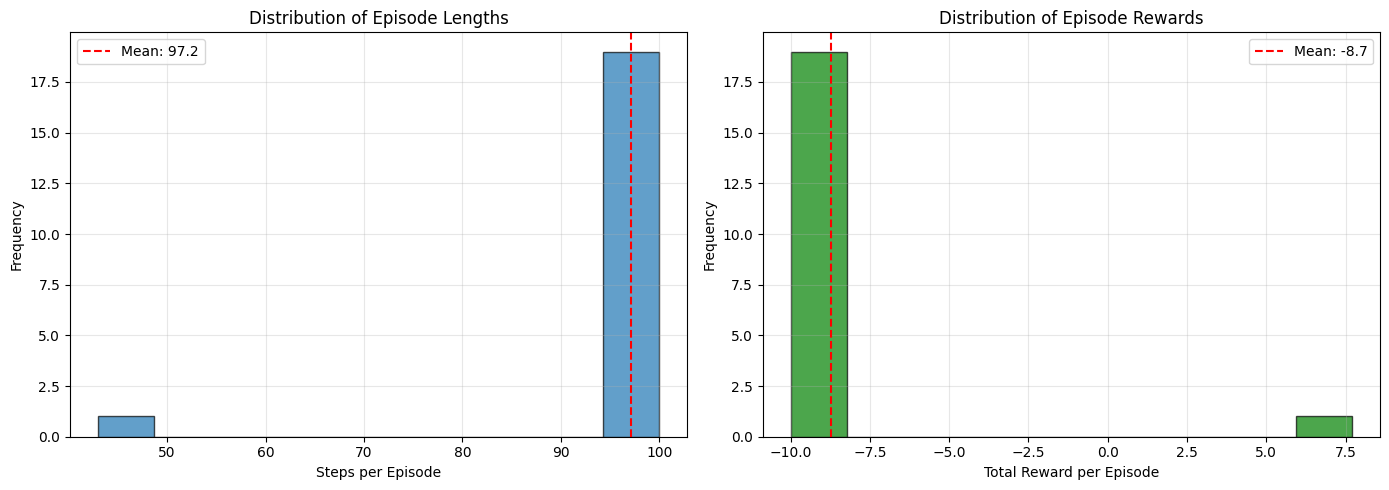

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot steps distribution
axes[0].hist(steps, bins=10, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(steps), color='red', linestyle='--', label=f'Mean: {np.mean(steps):.1f}')
axes[0].set_xlabel('Steps per Episode')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Episode Lengths')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot rewards distribution
axes[1].hist(rewards, bins=10, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(np.mean(rewards), color='red', linestyle='--', label=f'Mean: {np.mean(rewards):.1f}')
axes[1].set_xlabel('Total Reward per Episode')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Episode Rewards')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Integration with Reinforcement Learning

The environment is ready for use with RL frameworks like Stable-Baselines3, RLlib, or custom implementations.

### Example RL Training Loop Structure

In [ ]:
# Pseudocode for RL training loop
"""
# Initialize environment and agent
env = SokobanEnv(dim_room=(7, 7), max_steps=120, num_boxes=2, render_mode='rgb_array')
agent = YourRLAgent(env.observation_space, env.action_space)

# Training loop
for episode in range(num_episodes):
    observation, info = env.reset()
    episode_reward = 0
    
    while True:
        # Agent selects action
        action = agent.select_action(observation)
        
        # Environment step
        next_observation, reward, terminated, truncated, info = env.step(action)
        
        # Agent learns from experience
        agent.learn(observation, action, reward, next_observation, terminated or truncated)
        
        observation = next_observation
        episode_reward += reward
        
        if terminated or truncated:
            break
    
    print(f"Episode {episode}: Reward = {episode_reward:.2f}")
"""
print("See the pseudocode above for RL integration structure")

## Summary

This notebook covered:
1. ✅ Creating Sokoban environments (direct and via `gym.make()`)
2. ✅ Understanding the action and observation spaces
3. ✅ Basic environment interaction (reset, step, render)
4. ✅ Running full episodes with visualization
5. ✅ Understanding the reward structure
6. ✅ Working with different room configurations
7. ✅ Seeding for reproducibility
8. ✅ Building simple agents
9. ✅ Batch processing and statistics
10. ✅ Integration with RL frameworks

### Key Takeaways

- The environment follows the **Gymnasium 1.0.0 API** standard
- `reset()` returns `(observation, info)`
- `step()` returns `(observation, reward, terminated, truncated, info)`
- Seeding ensures reproducible experiments
- The environment is fully compatible with modern RL frameworks

### Next Steps

- Train a Deep Q-Network (DQN) or PPO agent
- Experiment with different reward shaping strategies
- Try curriculum learning with increasing difficulty
- Implement behavioral cloning from expert demonstrations

## Cleanup

In [34]:
# Close the environment when done
env.close()
print("Environment closed successfully!")

Environment closed successfully!
